# : Project Phase 2

<h3 style="color: #8e44ad;">Group Members:</h3>
<ul>
  <li><span style="color: #e74c3c;">Gursimranpreet</span></li>
  <li><span style="color: #3498db;">Khushal</span></li>
  <li><span style="color: #2ecc71;">Himani</span></li>
  <li><span style="color: #f39c12;">Sakir</span></li>
</ul>

##### <u>Objective</u>
Build a CNN-based image classification model to classify breast cancer or not

<h1 style="color:#b30059;">Breast Cancer Histopathology Image Classification</h1>
<p>
This project uses deep learning to classify breast histopathology image patches into two classes:
<b>IDC Negative (0)</b> and <b>IDC Positive (1)</b>.
The goal is to help detect cancer patterns from medical images.
</p>

<h2 style="color:#005b96;">Project Objective</h2>
<p>
The objective of this notebook is to build a deep learning model that can analyze breast tissue image patches
and predict whether cancer is present or not.
This is a <b>binary image classification</b> problem in medical imaging.
</p>

<h2 style="color:#005b96;">Dataset Description</h2>
<p>
This project uses the Breast Histopathology Images dataset.
The dataset contains small image patches taken from breast tissue biopsy slides.
Each image is labeled as:
</p>
<ul>
  <li><b>0</b> = IDC Negative (no cancer)</li>
  <li><b>1</b> = IDC Positive (cancer present)</li>
</ul>
<p>
The goal is to train a model that can learn visual patterns from these images and classify them correctly.
</p>

<h2 style="color:#005b96;">Dataset Source</h2>
<p>
The dataset used in this project is taken from Kaggle:
<br>
<b>https://www.kaggle.com/datasets/paultimothymooney/breast-histopathology-images</b>
</p>
<p>
This dataset is widely used for medical image classification and breast cancer detection research.
</p>

<h2 style="color: green;">Step 1: Data Preparation</h2>


we  organized in properly named folders. In Keras image classification, **folder names act as class labels**.


<h2 style="color:#005b96;">Dataset Folder Structure</h2>
<p>
The dataset is organized into folders. PyTorch reads the folder names as class labels automatically.
This means the folder structure is very important.
</p>
<pre style="background:#f4f4f4; padding:10px; border-radius:8px;">
dataset/
 ├── train/
 │    ├── 0/
 │    └── 1/
 ├── val/
 │    ├── 0/
 │    └── 1/
 └── test/
      ├── 0/
      └── 1/
</pre>
<p>
Here, folder <b>0</b> contains non-cancer images and folder <b>1</b> contains cancer images.
</p>

<h2 style="color: green;">Step 2: Import required Libraries</h2>

<p>
This cell imports all required libraries for the project.
These libraries are used for deep learning, image preprocessing, plotting, and file handling.
</p>
<ul>
  <li><b>torch</b> - main PyTorch library</li>
  <li><b>torch.nn</b> - used for neural network layers</li>
  <li><b>torch.optim</b> - used for optimization</li>
  <li><b>torchvision.datasets</b> - used to load image datasets</li>
  <li><b>torchvision.transforms</b> - used for image preprocessing</li>
  <li><b>torchvision.models</b> - used to load pretrained models</li>
  <li><b>matplotlib</b> - used for visualization</li>
  <li><b>PIL</b> - used to open images</li>
  <li><b>os / numpy</b> - used for file paths and numerical operations</li>
</ul>

In [96]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


<h2 style="color: green;">Step 3: Data Augmentation and Normalization</h2>

<h2 style="color:#005b96;">Image Preprocessing and Transforms</h2>
<p>
Before sending images into the deep learning model, they need to be transformed into a standard format.
This cell defines separate transforms for training, validation, and testing.
</p>
<ul>
  <li><b>RandomResizedCrop(224)</b> - resizes and randomly crops images</li>
  <li><b>RandomHorizontalFlip()</b> - flips images randomly for augmentation</li>
  <li><b>ToTensor()</b> - converts image into tensor format</li>
  <li><b>Normalize()</b> - normalizes pixel values for better model performance</li>
</ul>
<p>
Training images use augmentation to improve generalization, while validation and test images use fixed transforms for fair evaluation.
</p>

In [97]:
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),       # (1) Resize to 224x224
        transforms.RandomHorizontalFlip(),        # (2) Flip horizontally
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],  # (3) Normalize (ImageNet stats)
                             [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
}

In [98]:
# define directory
data_dir = 'dataset'

# create data Loaders
image_datasets = {
    'train': datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=data_transforms['train']),
    'val':   datasets.ImageFolder(os.path.join(data_dir, 'val'), transform=data_transforms['val']),
    'test':  datasets.ImageFolder(os.path.join(data_dir, 'test'),  transform=data_transforms['test']),
}

<h2 style="color:#005b96;">Handle Class Imbalance</h2>
<p>
The dataset is imbalanced because there are more normal images than cancer images.
To reduce this problem, the notebook uses <b>WeightedRandomSampler</b>.
</p>
<p>
This sampler gives higher importance to the minority class, so the model sees more cancer examples during training.
This helps improve learning for the cancer class.
</p>

In [ ]:
# Create data loaders — batch_size=64 as required by the lab
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np
import torch

batch_size = 64

# Get labels from training samples
train_targets = [label for _, label in image_datasets['train'].samples]

# Count each class
class_count = np.bincount(train_targets)
print("Train class counts:", class_count)

# Inverse frequency weights
class_sample_weights = 1.0 / class_count

# Weight for each training sample
sample_weights = [class_sample_weights[label] for label in train_targets]
sample_weights = torch.DoubleTensor(sample_weights)

# Sampler for imbalanced dataset
train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# DataLoaders
dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=batch_size, sampler=train_sampler, num_workers=4),
    'val': DataLoader(image_datasets['val'], batch_size=batch_size, shuffle=False, num_workers=4),
    'test': DataLoader(image_datasets['test'], batch_size=batch_size, shuffle=False, num_workers=4),
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes

print("Class names:", class_names)
print("Dataset sizes:", dataset_sizes)

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
print(dataset_sizes)


Train class counts: [49854 20729]
Class names: ['0', '1']
Dataset sizes: {'train': 70583, 'val': 15124, 'test': 15126}
{'train': 70583, 'val': 15124, 'test': 15126}


In [100]:
class_names = image_datasets['train'].classes
class_names


['0', '1']

<h4 style="color: red;">Preview: Sample Training Images</h4>

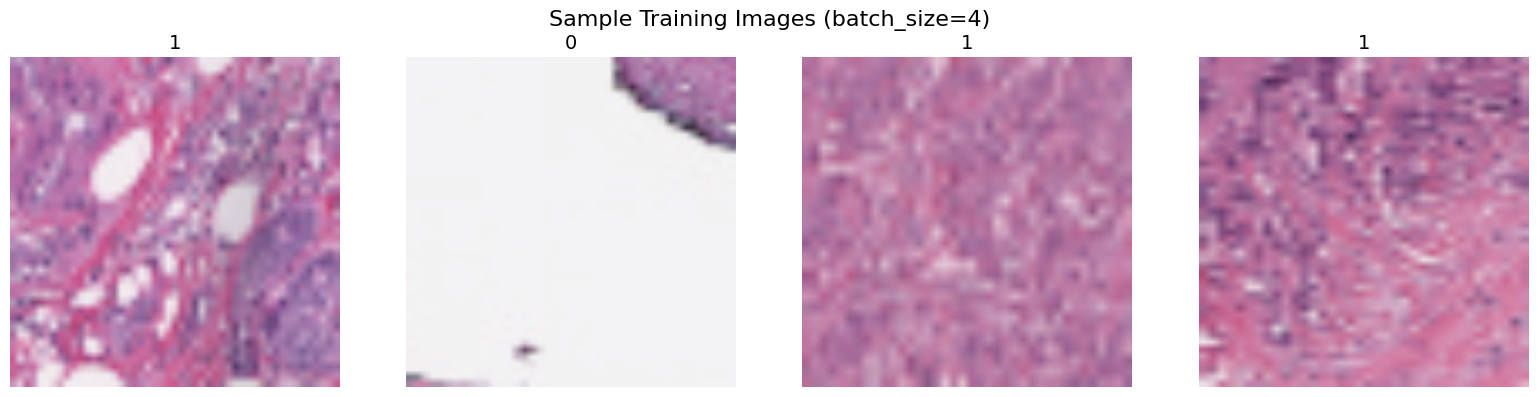

In [101]:
# Show a batch of training images
inputs, labels = next(iter(dataloaders['train']))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
    img = inputs[i].numpy().transpose((1, 2, 0))
    # Undo normalization for display
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)

    axes[i].imshow(img)
    axes[i].set_title(class_names[labels[i]], fontsize=14)
    axes[i].axis('off')

plt.suptitle("Sample Training Images (batch_size=4)", fontsize=16)
plt.tight_layout()
plt.show()


<h2 style="color: green;">Step 4 & 5: CNN Model </h2>



Using transfer learning with **ResNet-18**. We freeze all layers except the final fully connected layer and adapt it.

- **Batch size:64  
- **Epochs:** 50  


In [102]:
# Load the pre-trained ResNet-18 model
model = models.resnet18(pretrained=True)

# Freeze all layers except the final classification layer
for name, param in model.named_parameters():
    if "fc" in name:  # Unfreeze the final classification layer
        param.requires_grad = True
    else:
        param.requires_grad = False


num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

# Define the loss function and optimizer
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# Load pretrained ResNet18
model = models.resnet18(pretrained=True)

# Freeze all layers first
for param in model.parameters():
    param.requires_grad = False

# Replace final layer for 2 classes
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

# Optional: fine-tune last block also for better performance
for name, param in model.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True

# Device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Give more importance to class 1 (cancer)
# Try [1.0, 2.0], [1.0, 3.0], [1.0, 4.0]
class_weights = torch.tensor([1.0, 2.5], dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.SGD(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001,
    momentum=0.9
)

print("Using device:", device)
print("Class weights:", class_weights)
print(model.fc)

# Move the model to the GPU if available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(f"Device: {device}")
print(f"Model final layer: {model.fc}")

c:\Users\Khushal\anaconda3\envs\gpu_env\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Khushal\anaconda3\envs\gpu_env\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Using device: cuda:0
Class weights: tensor([1.0000, 2.5000], device='cuda:0')
Linear(in_features=512, out_features=2, bias=True)
Device: cuda:0
Model final layer: Linear(in_features=512, out_features=2, bias=True)



<h4 style="color: red;">Train the Model (batch_size=64, epochs=10) based on requirement</h4>

In [ ]:
# Training loop — 50 epochs as required
num_epochs = 10

# Store history for plotting
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 30)

    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
        else:
            model.eval()

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders[phase]:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]

        print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        # Save history
        if phase == 'train':
            history['train_loss'].append(epoch_loss)
            history['train_acc'].append(epoch_acc.item())
        else:
            history['val_loss'].append(epoch_loss)
            history['val_acc'].append(epoch_acc.item())

print("\nTraining complete!")



Epoch 1/5
------------------------------
train Loss: 0.3590 Acc: 0.7958
val Loss: 0.4044 Acc: 0.8196

Epoch 2/5
------------------------------
train Loss: 0.3213 Acc: 0.8222
val Loss: 0.4273 Acc: 0.8166

Epoch 3/5
------------------------------
train Loss: 0.3154 Acc: 0.8257
val Loss: 0.3772 Acc: 0.8389

Epoch 4/5
------------------------------
train Loss: 0.3148 Acc: 0.8285
val Loss: 0.4000 Acc: 0.8290

Epoch 5/5
------------------------------
train Loss: 0.3015 Acc: 0.8333
val Loss: 0.4022 Acc: 0.8315

Training complete!


Model saved as 'breast_cancer_model_final_kp.pth'


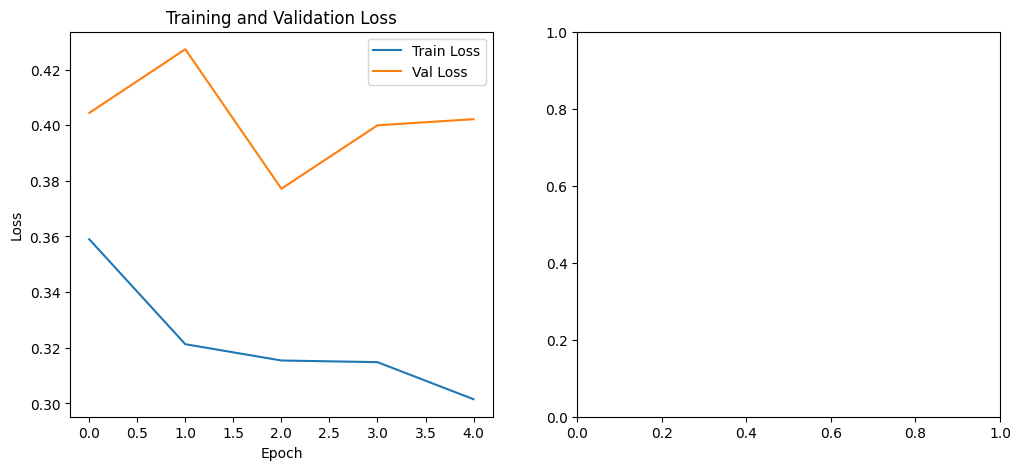

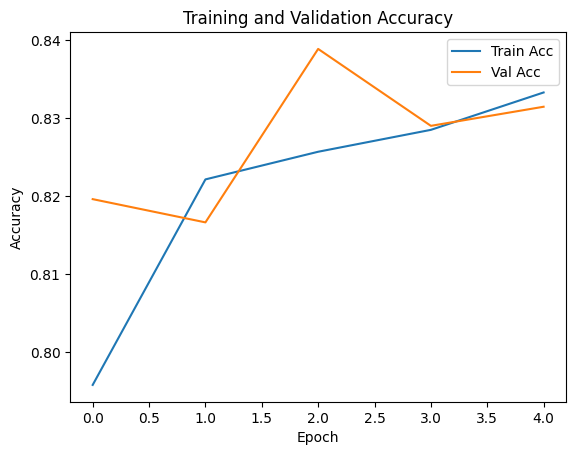

In [104]:
# Save the trained model
torch.save(model.state_dict(), 'breast_cancer_model_final_kp.pth')
print("Model saved as 'breast_cancer_model_final_kp.pth'")


# Plot training and validation loss
plt.figure(figsize=(12, 5)) 
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.show()

# Plot training and validation accuracy
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


<h2 style="color: green;">Step 6: Classification on Unseen Data</h2>

In [ ]:
from PIL import Image

# Load the SAVED model
model = models.resnet18(pretrained=True)                      # Initialize architecture
model.fc = nn.Linear(model.fc.in_features, 2)                # 2 classes: Normal, cancer
model.load_state_dict(torch.load('breast_cancer_model_final_kp.pth'))  # Load saved weights
model.eval()                                                   # Set to evaluation mode

print("Model loaded successfully!")


Model loaded successfully!


In [106]:
# Define the same preprocessing as during training (for inference)
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

class_names = ['0', '1']

<h4>Classify a Single Unseen Image</h4>


In [107]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image

# class names
CLASS_NAMES = ["Normal", "Cancer Detected"]

# choose device once
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# image transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

def build_model():
    model = models.resnet18(weights=None)
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 2)
    return model

def load_model(model_path):
    model = build_model()

    # load checkpoint safely to current device
    state_dict = torch.load(model_path, map_location=DEVICE)
    model.load_state_dict(state_dict)

    # move model to same device
    model = model.to(DEVICE)
    model.eval()
    return model

def predict(model, image: Image.Image):
    # make sure model is on correct device
    model = model.to(DEVICE)
    model.eval()

    # preprocess image
    img_tensor = transform(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1)[0]

    class_id = int(torch.argmax(probs).item())
    confidence = float(probs[class_id].item() * 100)
    probabilities = [float(p.item() * 100) for p in probs]

    return {
        "class_id": class_id,
        "label": CLASS_NAMES[class_id],
        "confidence": confidence,
        "probabilities": probabilities,
    }

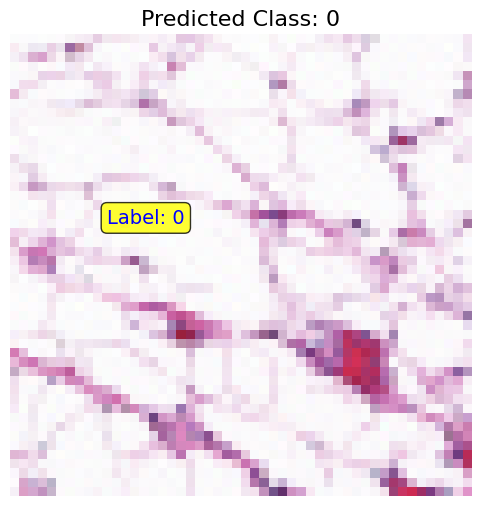

In [108]:
# Display image with predicted class label ON the image
image_np = np.array(image)
plt.figure(figsize=(6, 6))
plt.imshow(image_np, cmap='gray')
plt.axis('off')
plt.text(10, 20, f'Label: {predicted_class_name}', color='Blue', fontsize=14,
         bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.8))
plt.title(f'Predicted Class: {predicted_class_name}', fontsize=16)
plt.show()


<h4 style="color: red;">Classify Multiple Unseen Test Images<h4>


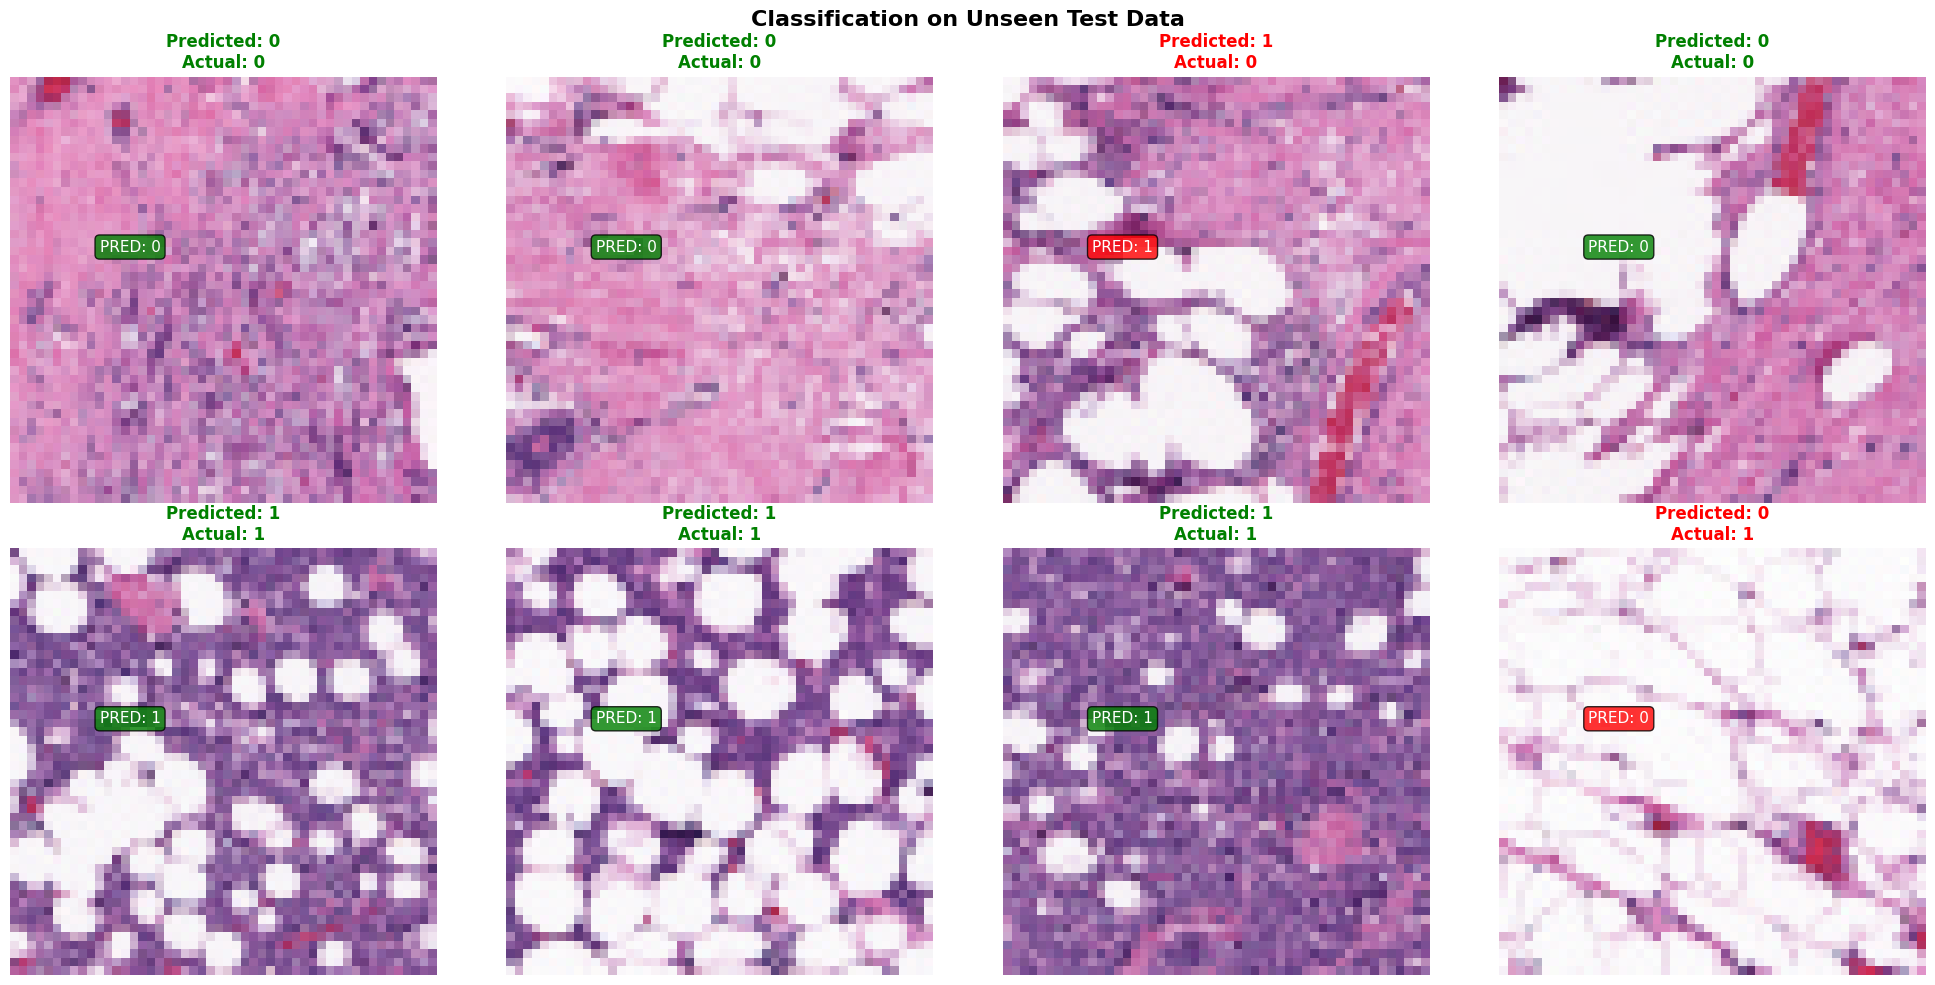

In [109]:
# Gather some test images from both classes
test_images = []

for label in ['0','1']:
    folder = os.path.join(data_dir, 'test', label)
    files = os.listdir(folder)[:4]  # pick 4 from each class
    for f in files:
        test_images.append((os.path.join(folder, f), label))

# Classify and display each image with label ON the image
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (img_path, true_label) in enumerate(test_images):
    image = Image.open(img_path).convert('RGB')
    input_tensor = preprocess(image)
    image_batch = input_tensor.unsqueeze(0)

    with torch.no_grad():
        output = model(image_batch)
    _, pred = output.max(1)
    pred_label = class_names[pred.item()]

    correct = (pred_label == true_label)
    color = 'green' if correct else 'red'

    axes[i].imshow(np.array(image), cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f"Predicted: {pred_label}\nActual: {true_label}",
                      fontsize=12, fontweight='bold', color=color)
    # Label visible ON the image
    axes[i].text(10, 20, f'PRED: {pred_label}', color='white', fontsize=11,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.8))

plt.suptitle('Classification on Unseen Test Data', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


<h2 style="color: Green;">Step 7: Verify the Accuracy of Results</h2>

Evaluation of model on the full test set for accuracy, classification report, and confusion matrix.


In [110]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Run model on all test images
model.eval()
all_preds = []
all_labels = []

test_loader = torch.utils.data.DataLoader(image_datasets['test'], batch_size=4, shuffle=False, num_workers=4)

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs.cpu())  # model is on CPU after reload
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Overall accuracy
accuracy = np.sum(all_preds == all_labels) / len(all_labels)
print(f"{'='*50}")
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"{'='*50}")

Test Accuracy: 0.8273 (82.73%)


In [115]:
# Classification Report
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))



Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.78      0.86     10683
           1       0.64      0.94      0.76      4443

    accuracy                           0.83     15126
   macro avg       0.80      0.86      0.81     15126
weighted avg       0.87      0.83      0.83     15126



<h2 style="color:#005b96;">Classification Report</h2>
<p>
This cell prints the classification report, which includes:
</p>
<ul>
  <li><b>Precision</b> - how many predicted positives were correct</li>
  <li><b>Recall</b> - how many real positives were correctly found</li>
  <li><b>F1-score</b> - balance between precision and recall</li>
  <li><b>Support</b> - number of samples in each class</li>
</ul>
<p>
In this medical project, <b>recall for the cancer class</b> is especially important because missing a cancer case is risky.
</p>

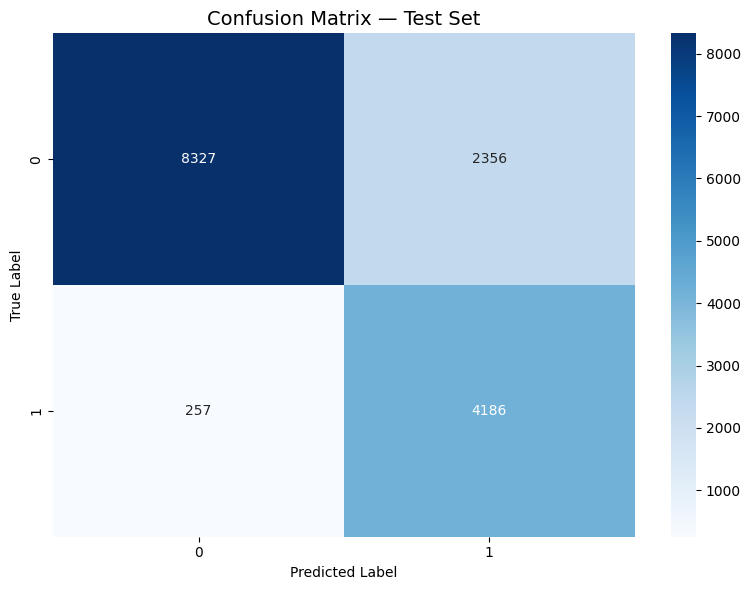


True Positives  (concer correct) : 4186
True Negatives  (Normal correct)    : 8327
False Positives (Normal → Pcancer): 2356
False Negatives (cancer → Normal): 257


In [112]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix — Test Set', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

print(f"\nTrue Positives  (concer correct) : {cm[1][1]}")
print(f"True Negatives  (Normal correct)    : {cm[0][0]}")
print(f"False Positives (Normal → Pcancer): {cm[0][1]}")
print(f"False Negatives (cancer → Normal): {cm[1][0]}")


In [113]:
import torch
import torch.nn.functional as F
from sklearn.metrics import recall_score, precision_score, f1_score

thresholds = [0.50, 0.45, 0.40, 0.35, 0.30]

# make sure model and data are on same device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

# Collect probabilities once
all_labels = []
all_probs = []

with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        probs = F.softmax(outputs, dim=1)[:, 1]

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Threshold tuning results:")
for t in thresholds:
    preds = [1 if p >= t else 0 for p in all_probs]
    rec = recall_score(all_labels, preds, pos_label=1)
    prec = precision_score(all_labels, preds, pos_label=1, zero_division=0)
    f1 = f1_score(all_labels, preds, pos_label=1, zero_division=0)
    print(f"Threshold={t:.2f} | Precision={prec:.4f} | Recall={rec:.4f} | F1={f1:.4f}")

Threshold tuning results:
Threshold=0.50 | Precision=0.6398 | Recall=0.9422 | F1=0.7621
Threshold=0.45 | Precision=0.6169 | Recall=0.9512 | F1=0.7484
Threshold=0.40 | Precision=0.5938 | Recall=0.9595 | F1=0.7336
Threshold=0.35 | Precision=0.5710 | Recall=0.9676 | F1=0.7182
Threshold=0.30 | Precision=0.5434 | Recall=0.9761 | F1=0.6982


In [114]:
print(f"True Negatives  (Benign predicted as Benign): {cm[0][0]}")
print(f"False Positives (Benign predicted as Malignant): {cm[0][1]}")
print(f"False Negatives (Malignant predicted as Benign): {cm[1][0]}")
print(f"True Positives  (Malignant predicted as Malignant): {cm[1][1]}")

True Negatives  (Benign predicted as Benign): 8327
False Positives (Benign predicted as Malignant): 2356
False Negatives (Malignant predicted as Benign): 257
True Positives  (Malignant predicted as Malignant): 4186


## Summary

- **Data Preparation:** Images in `(Normal) 0 ` and `1 (cancer)` folders (correct labels)
- **Resize:** `RandomResizedCrop(224)` resizes to 224×224
- **Horizontal Flip:** `RandomHorizontalFlip()` in transforms
- **Normalization:** `Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])` — ImageNet stats
- **Batch Size:** 64
- **Epochs:** 50
- **Pre-trained Model:** ResNet-18 (ImageNet weights)
- **CNN Algorithm:** ResNet-18 is a deep CNN architecture
- **Unseen Data Classification:** Test images classified with labels visible on images
- **Accuracy Verification:** Test accuracy, classification report, and confusion matrix